<a href="https://colab.research.google.com/github/Smarth2005/Python-Hands-On/blob/main/Data%20Visualization/Data%20Visualization%20using%20Plotnine%20and%20ggplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install plotnine

In [ ]:
pip install plotly

In [ ]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as pyplot
from matplotlib import font_manager as fmgr

from pandas.plotting import scatter_matrix
from pandas.plotting import autocorrelation_plot

import plotnine
from plotnine import ggplot, geom_line, aes

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

from datetime import datetime, timedelta

### Line Plot

In [ ]:
work_years = [1,2,3,4,5]
income = [65000, 90000, 150000, 147000, 122000]

df = pd.DataFrame({
    'Work Experience in years': work_years,
    'Income': income
})

In [ ]:
df.head()

,Work Experience in years,Income
0,1,65000
1,2,90000
2,3,150000
3,4,147000
4,5,122000


In [ ]:
lp = ggplot(data=df, mapping=aes(x="Work Experience in years", y="Income"))

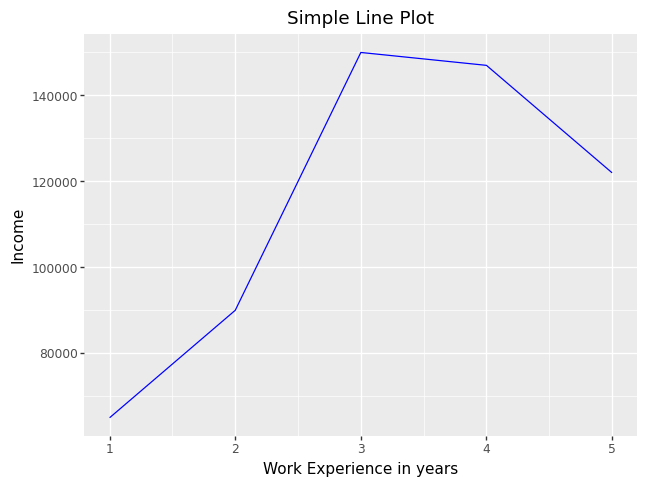

In [ ]:
(lp + plotnine.geom_line(color="blue") + plotnine.labs(title="Simple Line Plot")).draw()

In [ ]:
# Multi-line Plot
work_years = [1,2,3,4]
ml_engineers_income = [10000, 12000, 14000, 16000]
sde_income = [8000, 11000, 10000, 17000]

income_df = pd.DataFrame({
    "Years at work": work_years,
    "ML Engineers Income": ml_engineers_income,
    "SDE Income": sde_income
})

In [ ]:
income_df.head()

,Years at work,ML Engineers Income,SDE Income
0,1,10000,8000
1,2,12000,11000
2,3,14000,10000
3,4,16000,17000


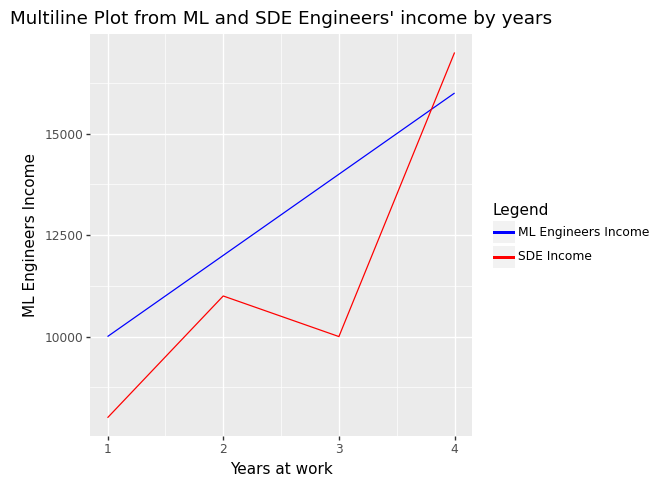

In [ ]:
(ggplot()+
 plotnine.geom_line(data=income_df, mapping=aes(x="Years at work", y="ML Engineers Income", color="'blue'"))+
 plotnine.geom_line(data=income_df, mapping=aes(x="Years at work", y="SDE Income", color="'red'"))+
 plotnine.labs(title="Multiline Plot from ML and SDE Engineers' income by years")+
 plotnine.scale_color_identity(guide="legend", name="Legend", breaks=["blue","red"], labels=["ML Engineers Income", "SDE Income"])).draw()

### Bar Plot

In [ ]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


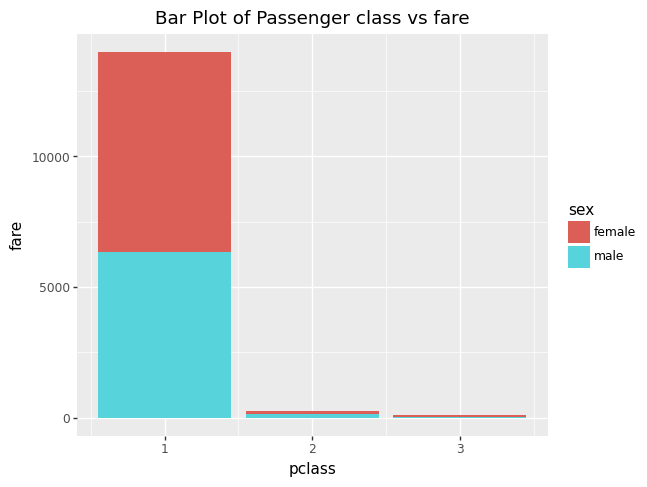

In [ ]:
(plotnine.ggplot(data=df.dropna(), mapping=aes(x='pclass', y='fare', fill='sex'))+
 plotnine.geom_col()+
 plotnine.labs(title="Bar Plot of Passenger class vs fare")).draw()

### Scatter Plot

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning:

geom_point : Removed 177 rows containing missing values.



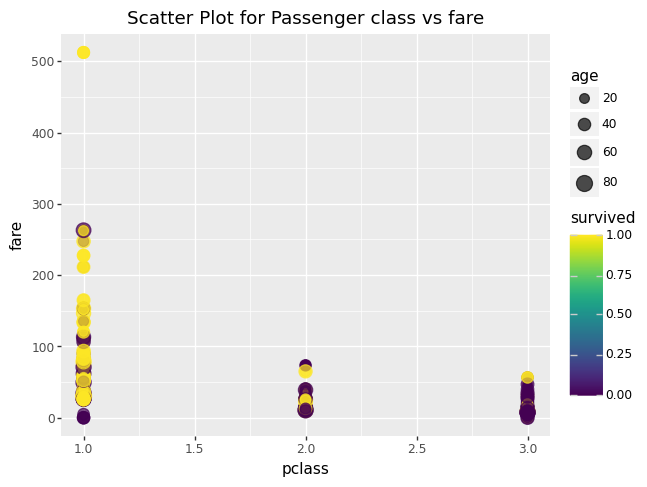

In [ ]:
scatter_plot = ggplot(data=df, mapping=aes(x='pclass', y='fare'))

(scatter_plot +
 plotnine.labs(title="Scatter Plot for Passenger class vs fare")+
 plotnine.geom_point(aes(size='age', color='survived'), shape='o', alpha=0.7)).draw()

### Histogram

/usr/local/lib/python3.12/dist-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning:

'stat_bin()' using 'bins = 5'. Pick better value with 'binwidth'.



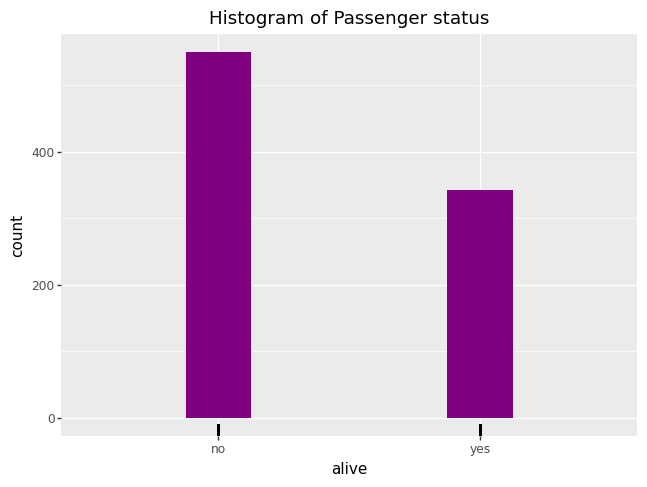

In [ ]:
hist = ggplot(data=df, mapping=aes(x='alive'))

(hist +
 plotnine.geom_histogram(fill='purple')+
 plotnine.geom_rug()+
 plotnine.labs(title="Histogram of Passenger status")).draw()

### Rug Plot

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning:

geom_point : Removed 177 rows containing missing values.



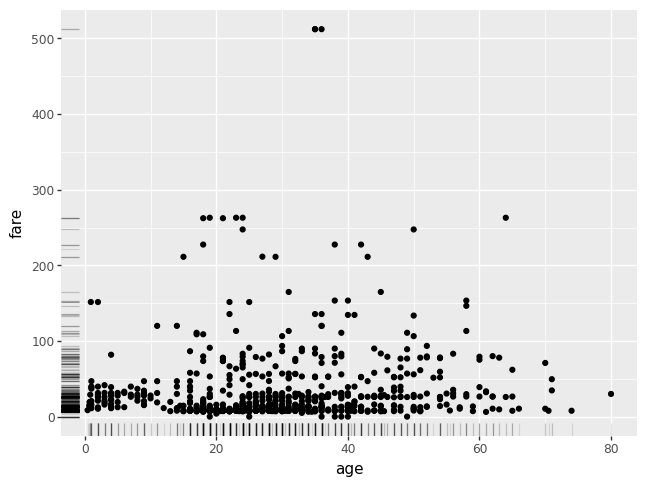

In [ ]:
# Scatter plot of Fare vs Age, with a rug plot on the axes
(ggplot(df, aes(x='age', y='fare')) +
plotnine.geom_point() +
plotnine.geom_rug(alpha=0.1)).draw()

### Density Plot

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:284: PlotnineWarning:

stat_density : Removed 177 rows containing non-finite values.



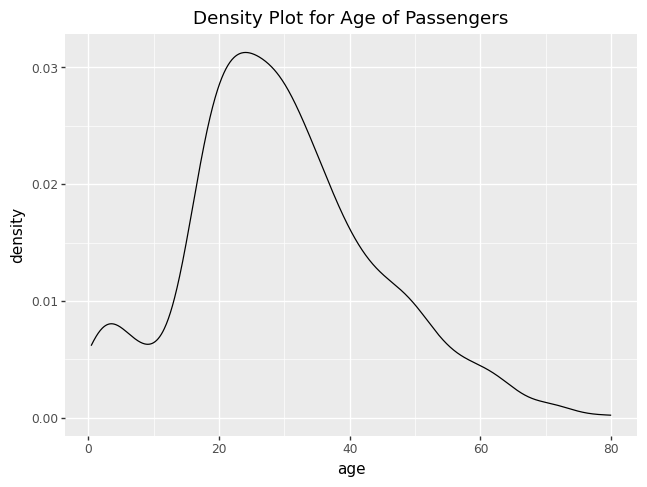

In [ ]:
kde = ggplot(data=df, mapping=aes('age'))

(kde+
 plotnine.geom_density()+
 plotnine.labs(title="Density Plot for Age of Passengers")).draw()

### Box Plot

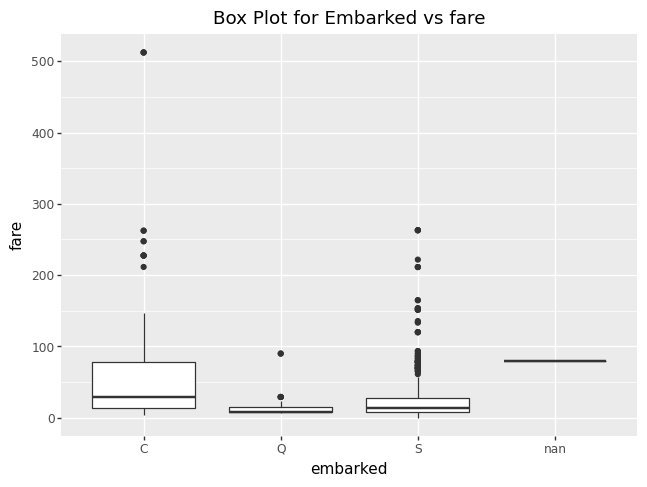

In [ ]:
bp = ggplot(data=df, mapping=aes(x='embarked', y='fare'))

(bp+
 plotnine.geom_boxplot()+
 plotnine.labs(title="Box Plot for Embarked vs fare")).draw()

### Violin Plot

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:284: PlotnineWarning:

stat_ydensity : Removed 177 rows containing non-finite values.

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning:

geom_jitter : Removed 177 rows containing missing values.



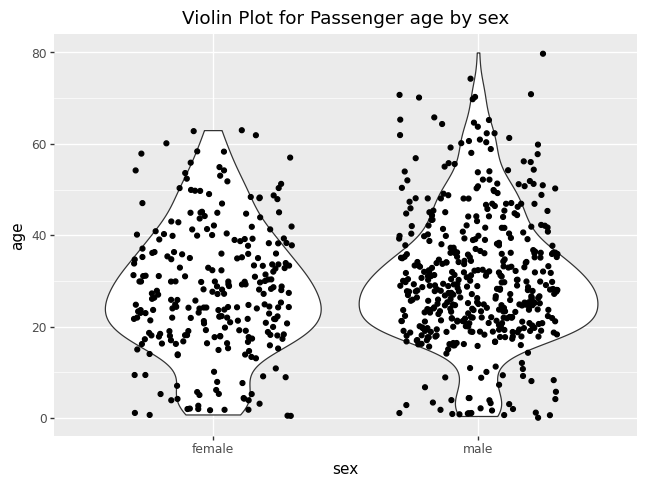

In [ ]:
vp = ggplot(data=df, mapping=aes(x='sex', y='age'))

(vp+
 plotnine.geom_violin()+
 plotnine.labs(title="Violin Plot for Passenger age by sex")+
 plotnine.geom_jitter(position=plotnine.position_jitter(0.3))).draw()